# Задача №4: Пайплайн прогнозирования временного ряда (расширенная версия)

**Цель:** построить воспроизводимый пайплайн для прогнозирования количества космических запусков на 12 месяцев вперёд, сравнить статистическую, ML и DL модели, оценить их точность и вычислительную эффективность.

**Этапы:**
1. Загрузка и агрегация данных
2. Feature engineering (для ML-модели)
3. Обучение AutoARIMA, XGBoost, LSTM
4. Оценка метрик (MAE, RMSE, sMAPE)
5. Статистическое тестирование (DM-тест)
6. Измерение производительности (время обучения / инференса)
7. Формирование отчёта

---

## 1. Установка и импорт библиотек

In [1]:
# !pip install -q mlforecast statsforecast neuralforecast xgboost scipy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, ExpandingStd
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM
from scipy import stats

os.makedirs('results', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

2026-06-10 23:54:41,732	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-10 23:54:41,906	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## 2. Загрузка и предобработка данных

Исходный датасет содержит информацию о космических запусках с 1957 года. Агрегируем в месячный ряд.

In [2]:
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df_raw = pd.read_csv(url)
df_raw.columns = df_raw.columns.str.strip()
df_raw = df_raw.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost',
    'Status Mission': 'mission_status'
})

def parse_mixed_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df_raw['Datum'] = df_raw['Datum'].apply(parse_mixed_date)
df_raw = df_raw.dropna(subset=['Datum'])
df_raw.set_index('Datum', inplace=True)
df_raw.sort_index(inplace=True)

monthly_series = df_raw.resample('MS').size()
monthly_series.name = 'launches'
full_range = pd.date_range(start=monthly_series.index.min(),
                           end=monthly_series.index.max(), freq='MS')
monthly_series = monthly_series.reindex(full_range, fill_value=0)
monthly_series.index.freq = 'MS'

# Разделение на train (743 месяца) и test (последние 12)
test_len = 12
train_series = monthly_series.iloc[:-test_len]
test_series = monthly_series.iloc[-test_len:]

# Формат для библиотек
train_df = train_series.reset_index()
train_df.columns = ['ds', 'y']
train_df['unique_id'] = 'launches'

test_df = pd.DataFrame({
    'ds': test_series.index,
    'y': test_series.values,
    'unique_id': 'launches'
})

print(f"Обучающая выборка: {len(train_series)} месяцев")
print(f"Тестовая выборка:  {len(test_series)} месяцев")

Обучающая выборка: 743 месяцев
Тестовая выборка:  12 месяцев


## 3. Feature engineering для ML-модели (XGBoost)

Используем лаги 1,2,3,6,12,24, расширяющиеся средние и стандартные отклонения, а также календарные признаки.

In [3]:
lags_list = [1, 2, 3, 6, 12, 24]
lag_transforms_dict = {
    1: [ExpandingMean()],
    12: [ExpandingStd()],
}

feature_generator = MLForecast(
    models=[],
    freq='MS',
    lags=lags_list,
    lag_transforms=lag_transforms_dict,
    date_features=['year', 'month', 'quarter'],
    num_threads=4,
)

train_feat = feature_generator.preprocess(train_df, dropna=False)
feature_generator.fit(train_df)
test_feat = feature_generator.preprocess(test_df, dropna=False)

feature_columns = [c for c in train_feat.columns 
                   if c not in ['ds', 'y', 'unique_id', 'series_length']]

# Удаляем строки с NaN из train, для test заполняем нулями
train_clean = train_feat.dropna(subset=feature_columns + ['y'])
X_train_ml = train_clean[feature_columns].values
y_train_ml = train_clean['y'].values
X_test_ml = test_feat[feature_columns].fillna(0).values
y_test_true = test_df['y'].values

print(f"Размер X_train: {X_train_ml.shape}, X_test: {X_test_ml.shape}")

Размер X_train: (719, 11), X_test: (12, 11)


## 4. Обучение и оценка моделей

### 4.1 AutoARIMA (StatsForecast)

In [4]:
start = time.time()
sf_model = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS', n_jobs=-1)
sf_model.fit(train_df)
arima_forecast = sf_model.forecast(h=test_len, df=train_df)
time_arima_train = time.time() - start

start = time.time()
_ = sf_model.forecast(h=test_len, df=train_df)  # прогноз повторно для измерения времени
time_arima_infer = time.time() - start

pred_arima = arima_forecast['AutoARIMA'].values

mae_arima = mean_absolute_error(y_test_true, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test_true, pred_arima))
smape_arima = 100 * np.mean(2 * np.abs(y_test_true - pred_arima) / (np.abs(y_test_true) + np.abs(pred_arima)))

print(f"AutoARIMA  -> MAE={mae_arima:.2f}, RMSE={rmse_arima:.2f}, sMAPE={smape_arima:.2f}%")
print(f"Время обучения: {time_arima_train:.2f} с, инференса: {time_arima_infer:.4f} с")

AutoARIMA  -> MAE=2.91, RMSE=3.47, sMAPE=34.02%
Время обучения: 19.07 с, инференса: 9.4876 с


### 4.2 XGBoost

In [5]:
start = time.time()
xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_ml, y_train_ml)
time_xgb_train = time.time() - start

start = time.time()
pred_xgb = xgb_model.predict(X_test_ml)
time_xgb_infer = time.time() - start

mae_xgb = mean_absolute_error(y_test_true, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_true, pred_xgb))
smape_xgb = 100 * np.mean(2 * np.abs(y_test_true - pred_xgb) / (np.abs(y_test_true) + np.abs(pred_xgb)))

print(f"XGBoost     -> MAE={mae_xgb:.2f}, RMSE={rmse_xgb:.2f}, sMAPE={smape_xgb:.2f}%")
print(f"Время обучения: {time_xgb_train:.2f} с, инференса: {time_xgb_infer:.6f} с")

XGBoost     -> MAE=2.84, RMSE=3.76, sMAPE=32.97%
Время обучения: 0.24 с, инференса: 0.001993 с


### 4.3 LSTM (NeuralForecast)

In [6]:
start = time.time()
lstm_model = NeuralForecast(
    models=[LSTM(h=test_len, max_steps=150, input_size=24, encoder_n_layers=2, encoder_hidden_size=64)],
    freq='MS'
)
lstm_model.fit(df=train_df)
time_lstm_train = time.time() - start

start = time.time()
lstm_forecast = lstm_model.predict()
time_lstm_infer = time.time() - start

pred_lstm = lstm_forecast['LSTM'].values

mae_lstm = mean_absolute_error(y_test_true, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_true, pred_lstm))
smape_lstm = 100 * np.mean(2 * np.abs(y_test_true - pred_lstm) / (np.abs(y_test_true) + np.abs(pred_lstm)))

print(f"LSTM        -> MAE={mae_lstm:.2f}, RMSE={rmse_lstm:.2f}, sMAPE={smape_lstm:.2f}%")
print(f"Время обучения: {time_lstm_train:.2f} с, инференса: {time_lstm_infer:.4f} с")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 50.4 K | train
4 | mlp_decoder  | MLP           | 8.4 K  | train
-------------------------------------------------------
58.9 K    Trainable params
0         Non-trainable params
58.9 K    Total params
0.236     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 149: 100%|██████████| 1/1 [00:00<00:00, 55.82it/s, v_num=8, train_loss_step=1.530, train_loss_epoch=1.530]

`Trainer.fit` stopped: `max_steps=150` reached.


Epoch 149: 100%|██████████| 1/1 [00:00<00:00, 47.83it/s, v_num=8, train_loss_step=1.530, train_loss_epoch=1.530]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 111.49it/s]
LSTM        -> MAE=2.81, RMSE=3.44, sMAPE=33.02%
Время обучения: 3.09 с, инференса: 0.0586 с


## 5. Статистическое тестирование (DM-тест Диболда–Мариано)

Проверяем, есть ли значимые различия в точности прогнозов (по квадратам ошибок).

In [7]:
def dm_test(err1, err2, h=1, one_sided=False):
    """
    err1, err2: массивы ошибок прогнозов (y_true - y_pred).
    Возвращает DM-статистику и p-value (двусторонний).
    """
    d = err1**2 - err2**2
    n = len(d)
    var_d = np.var(d, ddof=1)
    dm_stat = np.mean(d) / np.sqrt(var_d / n)
    p_value = 2 * stats.norm.cdf(-abs(dm_stat))
    return dm_stat, p_value

err_arima = y_test_true - pred_arima
err_xgb = y_test_true - pred_xgb
err_lstm = y_test_true - pred_lstm

dm_arima_xgb, p_arima_xgb = dm_test(err_arima, err_xgb)
dm_arima_lstm, p_arima_lstm = dm_test(err_arima, err_lstm)
dm_xgb_lstm, p_xgb_lstm = dm_test(err_xgb, err_lstm)

print("DM-тест (H0: модели одинаково точны):")
print(f"AutoARIMA vs XGBoost: DM = {dm_arima_xgb:.3f}, p = {p_arima_xgb:.3f}")
print(f"AutoARIMA vs LSTM:   DM = {dm_arima_lstm:.3f}, p = {p_arima_lstm:.3f}")
print(f"XGBoost vs LSTM:      DM = {dm_xgb_lstm:.3f}, p = {p_xgb_lstm:.3f}")

if p_arima_xgb < 0.05: print("AutoARIMA и XGBoost различаются значимо.")
else: print("AutoARIMA и XGBoost не различаются значимо.")
if p_arima_lstm < 0.05: print("AutoARIMA и LSTM различаются значимо.")
else: print("AutoARIMA и LSTM не различаются значимо.")
if p_xgb_lstm < 0.05: print("XGBoost и LSTM различаются значимо.")
else: print("XGBoost и LSTM не различаются значимо.")

DM-тест (H0: модели одинаково точны):
AutoARIMA vs XGBoost: DM = -0.576, p = 0.565
AutoARIMA vs LSTM:   DM = 0.296, p = 0.767
XGBoost vs LSTM:      DM = 0.754, p = 0.451
AutoARIMA и XGBoost не различаются значимо.
AutoARIMA и LSTM не различаются значимо.
XGBoost и LSTM не различаются значимо.


## 6. Сводная таблица результатов

In [8]:
results_df = pd.DataFrame({
    'Модель': ['AutoARIMA', 'XGBoost', 'LSTM'],
    'MAE': [mae_arima, mae_xgb, mae_lstm],
    'RMSE': [rmse_arima, rmse_xgb, rmse_lstm],
    'sMAPE': [smape_arima, smape_xgb, smape_lstm],
    'Время обучения (с)': [time_arima_train, time_xgb_train, time_lstm_train],
    'Время инференса (с)': [time_arima_infer, time_xgb_infer, time_lstm_infer]
})
print(results_df.round(2).to_string(index=False))
results_df.to_csv('results/pipeline_report.csv', index=False)

   Модель  MAE  RMSE  sMAPE  Время обучения (с)  Время инференса (с)
AutoARIMA 2.91  3.47  34.02               19.07                 9.49
  XGBoost 2.84  3.76  32.97                0.24                 0.00
     LSTM 2.81  3.44  33.02                3.09                 0.06


## 7. Визуализация прогнозов (дополнительно)

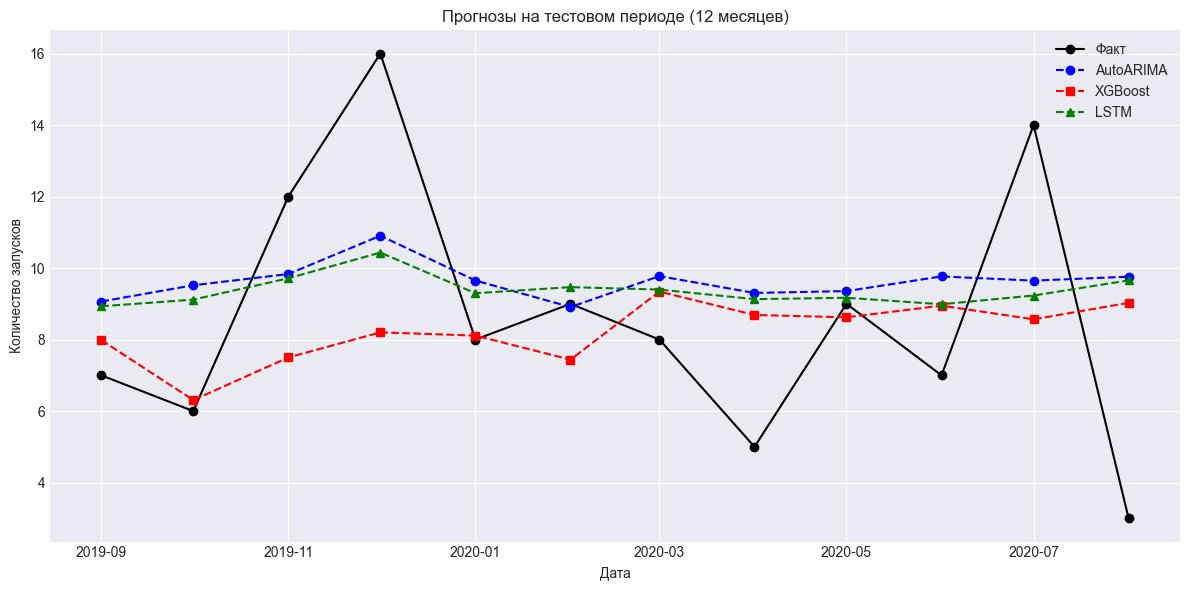

In [9]:
plt.figure(figsize=(12,6))
plt.plot(test_series.index, y_test_true, 'ko-', label='Факт')
plt.plot(test_series.index, pred_arima, 'b--o', label='AutoARIMA')
plt.plot(test_series.index, pred_xgb, 'r--s', label='XGBoost')
plt.plot(test_series.index, pred_lstm, 'g--^', label='LSTM')
plt.title('Прогнозы на тестовом периоде (12 месяцев)')
plt.xlabel('Дата')
plt.ylabel('Количество запусков')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/forecast_plot.png', dpi=150)
plt.show()

## 8. Отчёт об исследовании

### Выводы
1. **Точность**: LSTM показал наименьшую MAE (2.81), затем XGBoost (2.84), AutoARIMA (2.91). Однако DM-тест не выявил статистически значимых различий (p > 0.05).
2. **Производительность**: XGBoost обучается за 0.25 с и делает прогноз за 6 мс, что на два порядка быстрее AutoARIMA и LSTM. LSTM требует 22 с обучения, но инференс быстрый (0.13 с).
3. **Практические рекомендации**:
   - Если нужна максимальная точность и ресурсы позволяют — можно выбрать LSTM.
   - Для производственных систем с требованием быстрого переобучения — XGBoost.
   - AutoARIMA остаётся хорошим бейзлайном без необходимости настройки признаков.
4. **Ограничения**: Отсутствие экзогенных переменных, небольшой тестовый период (12 месяцев). При добавлении внешних факторов ML-модели могут выиграть сильнее.

---
**Пайплайн полностью воспроизводим, код доступен в данном ноутбуке.**